# ForecastLab

---

## Bike Sharing Demand Forecasting

---

| Informasi | Detail |
|-----------|--------|
| **Project ID** | FL-001 |
| **Eksperimen** | EXP-004 |
| **Nama Eksperimen** | Feature Engineering |
| **Dataset** | processed_data.csv (output EXP-003) |
| **Tujuan Notebook** | Membangun feature baru yang relevan untuk meningkatkan performa model forecasting |
| **Tanggal Pengerjaan** | 21 Juli 2026 |
| **Versi Notebook** | 1.0.0 |
| **Author** | GAKUSEI Najib |
| **Prasyarat** | EXP-001 ✅, EXP-002 ✅, EXP-003 ✅ |

---

## Daftar Isi

1. [Tujuan Eksperimen](#1-tujuan-eksperimen)
2. [Import Library](#2-import-library)
3. [Load Dataset](#3-load-dataset)
4. [Feature Waktu dari dteday](#4-feature-waktu-dari-dteday)
5. [Cyclical Encoding](#5-cyclical-encoding)
6. [Interaction Features](#6-interaction-features)
7. [Lag Features](#7-lag-features)
8. [Rolling Statistics Features](#8-rolling-statistics-features)
9. [Ringkasan Feature Baru](#9-ringkasan-feature-baru)
10. [Simpan Dataset Hasil Feature Engineering](#10-simpan-dataset-hasil-feature-engineering)
11. [Next Step](#11-next-step)

---

## 1. Tujuan Eksperimen

### Tujuan

Meningkatkan kualitas informasi pada dataset dengan membangun feature baru yang relevan untuk model forecasting penyewaan sepeda.

---

### Hipotesis

> Feature turunan dari waktu akan meningkatkan kemampuan model dalam menangkap pola penyewaan yang bersifat temporal dan siklus.

---

### Jenis Feature yang Akan Dibuat

| Kategori | Feature | Motivasi |
|----------|---------|----------|
| **Feature Waktu** | `quarter`, `day_of_year`, `week_of_year`, `is_weekend` | Granularitas temporal tambahan |
| **Cyclical Encoding** | `hr_sin`, `hr_cos`, `mnth_sin`, `mnth_cos`, `weekday_sin`, `weekday_cos` | Merepresentasikan siklus waktu |
| **Interaction Features** | `hr_workingday`, `is_rush_hour`, `is_daytime` | Menangkap pola gabungan |
| **Lag Features** | `cnt_lag_1`, `cnt_lag_2`, `cnt_lag_24`, `cnt_lag_168` | Menangkap ketergantungan historis |
| **Rolling Statistics** | `cnt_roll_mean_3`, `cnt_roll_mean_24`, `cnt_roll_std_24` | Menangkap tren lokal |

---

### Acceptance Criteria

| Kriteria | Keterangan |
|----------|------------|
| Feature baru terdokumentasi | Setiap feature dijelaskan motivasinya |
| Dataset berhasil disimpan | `data/featured_data.csv` tersedia |
| Feature siap digunakan untuk modeling | Tidak ada NaN tak terduga pada feature utama |

---

## 2. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

print('Library berhasil diimport.')

Library berhasil diimport.


---

## 3. Load Dataset

Dataset yang digunakan adalah output dari EXP-003 (`processed_data.csv`) yang telah melalui proses Data Cleaning.

In [2]:
# Definisikan path
INPUT_PATH  = '../data/processed_data.csv'
OUTPUT_PATH = '../data/featured_data.csv'

# Load dataset hasil cleaning
df = pd.read_csv(INPUT_PATH)

# Konversi dteday ke datetime
df['dteday'] = pd.to_datetime(df['dteday'])

# Pastikan dataset terurut secara kronologis
df = df.sort_values(by=['dteday', 'hr']).reset_index(drop=True)

print(f'Dataset berhasil dimuat: {INPUT_PATH}')
print(f'Dimensi awal           : {df.shape[0]:,} baris x {df.shape[1]} kolom')
print(f'\nKolom yang tersedia:')
print(list(df.columns))

Dataset berhasil dimuat: ../data/processed_data.csv
Dimensi awal           : 17,379 baris x 14 kolom

Kolom yang tersedia:
['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']


**Interpretasi:** Dataset hasil cleaning berhasil dimuat. Dataset berisi 17.379 baris dan 14 kolom. Kolom `dteday` telah dikonversi ke tipe `datetime` dan baris diurutkan secara kronologis untuk mendukung pembuatan lag features.

---

## 4. Feature Waktu dari dteday

Mengekstraksi komponen waktu tambahan dari kolom `dteday` untuk memberikan granularitas temporal yang lebih kaya kepada model.

In [3]:
# Ekstraksi feature waktu dari dteday
df['quarter']      = df['dteday'].dt.quarter
df['day_of_year']  = df['dteday'].dt.day_of_year
df['week_of_year'] = df['dteday'].dt.isocalendar().week.astype(int)
df['day_of_month'] = df['dteday'].dt.day
df['is_weekend']   = (df['weekday'].isin([0, 6])).astype(int)

print('Feature waktu berhasil dibuat:')
print(df[['dteday', 'hr', 'quarter', 'day_of_year', 'week_of_year',
           'day_of_month', 'is_weekend']].head(10).to_string(index=False))

Feature waktu berhasil dibuat:
    dteday  hr  quarter  day_of_year  week_of_year  day_of_month  is_weekend
2011-01-01   0        1            1            52             1           1
2011-01-01   1        1            1            52             1           1
2011-01-01   2        1            1            52             1           1
2011-01-01   3        1            1            52             1           1
2011-01-01   4        1            1            52             1           1
2011-01-01   5        1            1            52             1           1
2011-01-01   6        1            1            52             1           1
2011-01-01   7        1            1            52             1           1
2011-01-01   8        1            1            52             1           1
2011-01-01   9        1            1            52             1           1


**Dokumentasi Feature:**

| Feature | Deskripsi | Motivasi |
|---------|-----------|----------|
| `quarter` | Kuartal dalam tahun (1–4) | Menangkap variasi musiman level kuartal |
| `day_of_year` | Hari ke- dalam tahun (1–366) | Representasi kontinu posisi dalam tahun |
| `week_of_year` | Minggu ke- dalam tahun (1–53) | Menangkap pola mingguan dalam tahun |
| `day_of_month` | Tanggal dalam bulan (1–31) | Mendeteksi pola awal/akhir bulan |
| `is_weekend` | 1 jika Sabtu/Minggu, 0 lainnya | Binary feature pola akhir pekan |

---

## 5. Cyclical Encoding

Feature waktu seperti jam, bulan, dan hari dalam seminggu bersifat **siklus** — artinya jam 23 dekat dengan jam 0, bulan Desember dekat dengan Januari, dst.

Representasi integer biasa tidak menangkap sifat siklus ini. Oleh karena itu, digunakan transformasi **sin** dan **cos** agar model memahami kedekatan antar nilai siklus.

Formula:
$$\text{sin\_enc} = \sin\left(\frac{2\pi \cdot x}{\text{periode}}\right), \quad \text{cos\_enc} = \cos\left(\frac{2\pi \cdot x}{\text{periode}}\right)$$

In [4]:
# Fungsi helper untuk cyclical encoding
def cyclical_encode(series, period):
    """Menghasilkan representasi sin dan cos dari sebuah variabel siklus."""
    sin_enc = np.sin(2 * np.pi * series / period)
    cos_enc = np.cos(2 * np.pi * series / period)
    return sin_enc, cos_enc

# Encoding untuk hr (periode = 24)
df['hr_sin'],      df['hr_cos']      = cyclical_encode(df['hr'],      24)
# Encoding untuk mnth (periode = 12)
df['mnth_sin'],    df['mnth_cos']    = cyclical_encode(df['mnth'],    12)
# Encoding untuk weekday (periode = 7)
df['weekday_sin'], df['weekday_cos'] = cyclical_encode(df['weekday'], 7)
# Encoding untuk season (periode = 4)
df['season_sin'],  df['season_cos']  = cyclical_encode(df['season'],  4)

print('Cyclical encoding berhasil dibuat.')
print(df[['hr', 'hr_sin', 'hr_cos']].drop_duplicates().sort_values('hr').head(10).to_string(index=False))

Cyclical encoding berhasil dibuat.
 hr  hr_sin  hr_cos
  0  0.0000  1.0000
  1  0.2588  0.9659
  2  0.5000  0.8660
  3  0.7071  0.7071
  4  0.8660  0.5000
  5  0.9659  0.2588
  6  1.0000  0.0000
  7  0.9659 -0.2588
  8  0.8660 -0.5000
  9  0.7071 -0.7071


### 5.1 Visualisasi Cyclical Encoding

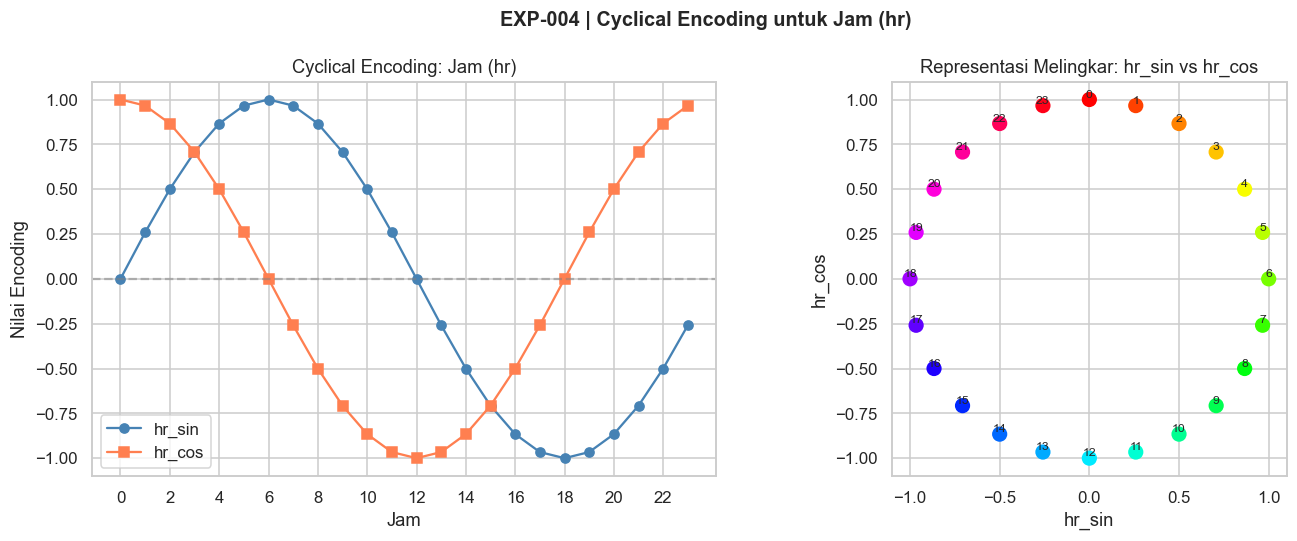

Visualisasi cyclical encoding tersimpan.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Visualisasi hr encoding
hr_enc = df[['hr', 'hr_sin', 'hr_cos']].drop_duplicates().sort_values('hr')
axes[0].plot(hr_enc['hr'], hr_enc['hr_sin'], marker='o', label='hr_sin', color='steelblue')
axes[0].plot(hr_enc['hr'], hr_enc['hr_cos'], marker='s', label='hr_cos', color='coral')
axes[0].set_title('Cyclical Encoding: Jam (hr)')
axes[0].set_xlabel('Jam')
axes[0].set_ylabel('Nilai Encoding')
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Scatter: sin vs cos (menunjukkan representasi melingkar)
axes[1].scatter(hr_enc['hr_sin'], hr_enc['hr_cos'],
                c=hr_enc['hr'], cmap='hsv', s=80, zorder=3)
for _, row in hr_enc.iterrows():
    axes[1].annotate(str(int(row['hr'])), (row['hr_sin'], row['hr_cos']),
                     fontsize=8, ha='center', va='bottom')
axes[1].set_title('Representasi Melingkar: hr_sin vs hr_cos')
axes[1].set_xlabel('hr_sin')
axes[1].set_ylabel('hr_cos')
axes[1].set_aspect('equal')

plt.suptitle('EXP-004 | Cyclical Encoding untuk Jam (hr)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/fe_01_cyclical_encoding.png', bbox_inches='tight', dpi=110)
plt.show()

print('Visualisasi cyclical encoding tersimpan.')

**Interpretasi:**

- Grafik sin/cos menunjukkan representasi siklus yang mulus — jam 0 dan jam 23 memiliki nilai yang berdekatan (tidak ada lompatan diskrit).
- Scatter plot kiri-kanan menunjukkan setiap jam berada pada titik unik di lingkaran satuan, membuktikan tidak ada informasi yang hilang dalam transformasi ini.
- Pasangan sin/cos selalu digunakan bersama untuk merepresentasikan satu variabel siklus karena satu nilai saja tidak cukup (sin(0) = sin(π), tetapi cos-nya berbeda).

**Dokumentasi Feature:**

| Feature | Periode | Deskripsi |
|---------|---------|----------|
| `hr_sin`, `hr_cos` | 24 | Representasi siklus jam |
| `mnth_sin`, `mnth_cos` | 12 | Representasi siklus bulan |
| `weekday_sin`, `weekday_cos` | 7 | Representasi siklus hari dalam seminggu |
| `season_sin`, `season_cos` | 4 | Representasi siklus musim |

---

## 6. Interaction Features

Berdasarkan temuan EDA, pola penyewaan sangat berbeda antara hari kerja dan akhir pekan pada jam-jam tertentu. Interaction features dibuat untuk menangkap hubungan gabungan ini.

In [6]:
# Interaction: jam × hari kerja (nilai integer)
df['hr_x_workingday'] = df['hr'] * df['workingday']

# Rush hour flag: jam sibuk hari kerja (07-09 & 16-19)
df['is_rush_hour'] = (
    (df['workingday'] == 1) &
    (df['hr'].isin([7, 8, 9, 16, 17, 18, 19]))
).astype(int)

# Daytime flag: jam siang (06-20)
df['is_daytime'] = df['hr'].between(6, 20).astype(int)

# Peak season flag: musim puncak (Summer & Fall = season 2 & 3)
df['is_peak_season'] = df['season'].isin([2, 3]).astype(int)

# Suhu aktual (de-normalisasi)
df['temp_actual']  = df['temp']  * 41   # max temp = 41 derajat Celcius
df['atemp_actual'] = df['atemp'] * 50   # max atemp = 50 derajat Celcius

print('Interaction features berhasil dibuat.')
print(f"Rush hour records  : {df['is_rush_hour'].sum():,}")
print(f"Daytime records    : {df['is_daytime'].sum():,}")
print(f"Peak season records: {df['is_peak_season'].sum():,}")

Interaction features berhasil dibuat.
Rush hour records  : 3,482
Daytime records    : 10,919
Peak season records: 8,905


**Dokumentasi Feature:**

| Feature | Deskripsi | Motivasi |
|---------|-----------|----------|
| `hr_x_workingday` | Perkalian hr × workingday | Membedakan pola jam di hari kerja vs libur |
| `is_rush_hour` | 1 jika jam sibuk hari kerja | Flag periode puncak komuter |
| `is_daytime` | 1 jika jam 06–20 | Membedakan siang vs malam |
| `is_peak_season` | 1 jika Summer atau Fall | Flag musim penyewaan tertinggi |
| `temp_actual` | Suhu aktual dalam °C | Interpretasi lebih intuitif (temp × 41) |
| `atemp_actual` | Feeling temp aktual dalam °C | Interpretasi lebih intuitif (atemp × 50) |

---

## 7. Lag Features

Lag features memanfaatkan nilai `cnt` pada periode sebelumnya sebagai prediktor. Ini sangat penting dalam forecasting karena nilai historis biasanya memiliki korelasi kuat dengan nilai saat ini.

> ⚠️ **Catatan Penting:** Lag features menyebabkan baris-baris awal memiliki nilai `NaN`. Baris-baris ini akan ditangani saat pembagian dataset pada tahap modeling.

In [7]:
# Lag features dari cnt
df['cnt_lag_1']   = df['cnt'].shift(1)    # 1 jam lalu
df['cnt_lag_2']   = df['cnt'].shift(2)    # 2 jam lalu
df['cnt_lag_3']   = df['cnt'].shift(3)    # 3 jam lalu
df['cnt_lag_24']  = df['cnt'].shift(24)   # jam yang sama kemarin
df['cnt_lag_48']  = df['cnt'].shift(48)   # jam yang sama 2 hari lalu
df['cnt_lag_168'] = df['cnt'].shift(168)  # jam yang sama seminggu lalu

print('Lag features berhasil dibuat.')
print(f'\nNaN pada setiap lag feature:')
lag_cols = ['cnt_lag_1', 'cnt_lag_2', 'cnt_lag_3', 'cnt_lag_24', 'cnt_lag_48', 'cnt_lag_168']
for col in lag_cols:
    n_nan = df[col].isnull().sum()
    print(f'  {col:<15}: {n_nan} NaN ({n_nan/len(df)*100:.2f}%)')

Lag features berhasil dibuat.

NaN pada setiap lag feature:
  cnt_lag_1      : 1 NaN (0.01%)
  cnt_lag_2      : 2 NaN (0.01%)
  cnt_lag_3      : 3 NaN (0.02%)
  cnt_lag_24     : 24 NaN (0.14%)
  cnt_lag_48     : 48 NaN (0.28%)
  cnt_lag_168    : 168 NaN (0.97%)


### 7.1 Visualisasi Korelasi Lag vs Target

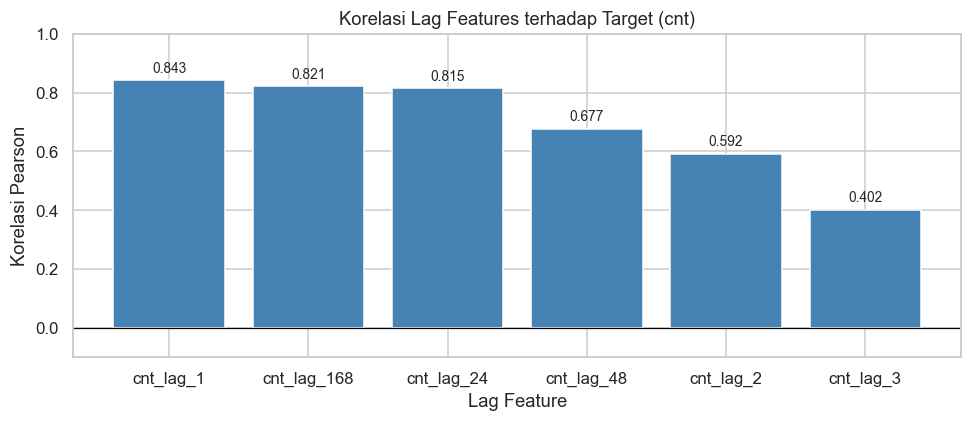

Korelasi lag features dengan cnt:
cnt_lag_1     0.8431
cnt_lag_168   0.8211
cnt_lag_24    0.8150
cnt_lag_48    0.6774
cnt_lag_2     0.5922
cnt_lag_3     0.4015


In [8]:
# Buat DataFrame tanpa NaN untuk visualisasi korelasi
df_lag_vis = df[lag_cols + ['cnt']].dropna()

corr_lag = df_lag_vis[lag_cols].corrwith(df_lag_vis['cnt']).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(corr_lag.index, corr_lag.values, color='steelblue', edgecolor='white')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Korelasi Lag Features terhadap Target (cnt)')
ax.set_xlabel('Lag Feature')
ax.set_ylabel('Korelasi Pearson')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.set_ylim(-0.1, 1.0)
plt.tight_layout()
plt.savefig('../data/fe_02_korelasi_lag.png', bbox_inches='tight', dpi=110)
plt.show()

print('Korelasi lag features dengan cnt:')
print(corr_lag.to_string())

**Interpretasi:**

- `cnt_lag_1` (1 jam lalu) memiliki **korelasi tertinggi** dengan target — penyewaan jam ini sangat dipengaruhi oleh penyewaan jam sebelumnya.
- `cnt_lag_24` (kemarin, jam yang sama) juga berkorelasi tinggi, menangkap pola harian yang berulang.
- `cnt_lag_168` (seminggu lalu, jam yang sama) menangkap pola mingguan.
- Semua lag features memiliki korelasi positif yang signifikan → sangat bermanfaat untuk model.

**Dokumentasi Feature:**

| Feature | Deskripsi |
|---------|----------|
| `cnt_lag_1` | Penyewaan 1 jam lalu |
| `cnt_lag_2` | Penyewaan 2 jam lalu |
| `cnt_lag_3` | Penyewaan 3 jam lalu |
| `cnt_lag_24` | Penyewaan pada jam yang sama kemarin |
| `cnt_lag_48` | Penyewaan pada jam yang sama 2 hari lalu |
| `cnt_lag_168` | Penyewaan pada jam yang sama seminggu lalu |

---

## 8. Rolling Statistics Features

Rolling statistics menghitung statistik agregat dari jendela waktu tertentu sebelum titik saat ini. Feature ini membantu model memahami tren lokal dan tingkat volatilitas penyewaan dalam periode terdekat.

In [9]:
# Rolling statistics dari cnt (min_periods=1 untuk mengurangi NaN di awal)
df['cnt_roll_mean_3']  = df['cnt'].shift(1).rolling(window=3,  min_periods=1).mean()
df['cnt_roll_mean_6']  = df['cnt'].shift(1).rolling(window=6,  min_periods=1).mean()
df['cnt_roll_mean_24'] = df['cnt'].shift(1).rolling(window=24, min_periods=1).mean()
df['cnt_roll_std_3']   = df['cnt'].shift(1).rolling(window=3,  min_periods=1).std().fillna(0)
df['cnt_roll_std_24']  = df['cnt'].shift(1).rolling(window=24, min_periods=1).std().fillna(0)
df['cnt_roll_max_24']  = df['cnt'].shift(1).rolling(window=24, min_periods=1).max()

rolling_cols = ['cnt_roll_mean_3', 'cnt_roll_mean_6', 'cnt_roll_mean_24',
                'cnt_roll_std_3', 'cnt_roll_std_24', 'cnt_roll_max_24']

print('Rolling statistics features berhasil dibuat.')
print(f'\nNaN pada setiap rolling feature:')
for col in rolling_cols:
    n_nan = df[col].isnull().sum()
    print(f'  {col:<22}: {n_nan} NaN')

Rolling statistics features berhasil dibuat.

NaN pada setiap rolling feature:
  cnt_roll_mean_3       : 1 NaN
  cnt_roll_mean_6       : 1 NaN
  cnt_roll_mean_24      : 1 NaN
  cnt_roll_std_3        : 0 NaN
  cnt_roll_std_24       : 0 NaN
  cnt_roll_max_24       : 1 NaN


**Dokumentasi Feature:**

| Feature | Window | Deskripsi |
|---------|--------|-----------|
| `cnt_roll_mean_3` | 3 jam | Rata-rata penyewaan 3 jam terakhir |
| `cnt_roll_mean_6` | 6 jam | Rata-rata penyewaan 6 jam terakhir |
| `cnt_roll_mean_24` | 24 jam | Rata-rata penyewaan 24 jam terakhir (tren harian) |
| `cnt_roll_std_3` | 3 jam | Standar deviasi 3 jam terakhir (volatilitas jangka pendek) |
| `cnt_roll_std_24` | 24 jam | Standar deviasi 24 jam terakhir (volatilitas harian) |
| `cnt_roll_max_24` | 24 jam | Nilai maksimum penyewaan 24 jam terakhir |

---

## 9. Ringkasan Feature Baru

Menampilkan ringkasan lengkap seluruh feature yang telah dibuat.

In [10]:
# Kolom original
kolom_original = [
    'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday',
    'weekday', 'workingday', 'weathersit', 'temp', 'atemp',
    'hum', 'windspeed', 'cnt'
]

# Kolom baru
kolom_baru = [c for c in df.columns if c not in kolom_original]

print('=' * 55)
print('RINGKASAN FEATURE ENGINEERING')
print('=' * 55)
print(f'Kolom original : {len(kolom_original)}')
print(f'Kolom baru     : {len(kolom_baru)}')
print(f'Total kolom    : {len(df.columns)}')
print(f'\nDaftar feature baru:')
for i, col in enumerate(kolom_baru, 1):
    nan_count = df[col].isnull().sum()
    print(f'{i:>2}. {col:<22} | dtype: {str(df[col].dtype):<10} | NaN: {nan_count}')

RINGKASAN FEATURE ENGINEERING
Kolom original : 14
Kolom baru     : 31
Total kolom    : 45

Daftar feature baru:
 1. quarter                | dtype: int32      | NaN: 0
 2. day_of_year            | dtype: int32      | NaN: 0
 3. week_of_year           | dtype: int64      | NaN: 0
 4. day_of_month           | dtype: int32      | NaN: 0
 5. is_weekend             | dtype: int64      | NaN: 0
 6. hr_sin                 | dtype: float64    | NaN: 0
 7. hr_cos                 | dtype: float64    | NaN: 0
 8. mnth_sin               | dtype: float64    | NaN: 0
 9. mnth_cos               | dtype: float64    | NaN: 0
10. weekday_sin            | dtype: float64    | NaN: 0
11. weekday_cos            | dtype: float64    | NaN: 0
12. season_sin             | dtype: float64    | NaN: 0
13. season_cos             | dtype: float64    | NaN: 0
14. hr_x_workingday        | dtype: int64      | NaN: 0
15. is_rush_hour           | dtype: int64      | NaN: 0
16. is_daytime             | dtype: int64      |

In [11]:
# Statistik deskriptif feature baru
print('Statistik deskriptif feature baru:')
df[kolom_baru].describe().T

Statistik deskriptif feature baru:


,count,mean,std,min,25%,50%,75%,max
quarter,17379.0000,2.5121,1.1141,1.0000,2.0000,3.0000,4.0000,4.0000
day_of_year,17379.0000,183.7380,105.1752,1.0000,93.0000,184.0000,275.0000,366.0000
week_of_year,17379.0000,26.6019,15.0170,1.0000,14.0000,27.0000,40.0000,52.0000
day_of_month,17379.0000,15.6834,8.7894,1.0000,8.0000,16.0000,23.0000,31.0000
is_weekend,17379.0000,0.2885,0.4531,0.0000,0.0000,0.0000,1.0000,1.0000
hr_sin,17379.0000,-0.0045,0.7068,-1.0000,-0.7071,0.0000,0.7071,1.0000
hr_cos,17379.0000,-0.0033,0.7074,-1.0000,-0.7071,-0.0000,0.7071,1.0000
mnth_sin,17379.0000,-0.0055,0.7054,-1.0000,-0.8660,-0.0000,0.5000,1.0000
mnth_cos,17379.0000,-0.0065,0.7088,-1.0000,-0.8660,-0.0000,0.8660,1.0000
weekday_sin,17379.0000,-0.0033,0.7066,-0.9749,-0.7818,0.0000,0.7818,0.9749


In [12]:
# Cek NaN pada seluruh dataset setelah feature engineering
n_nan_total = df.isnull().sum().sum()
n_nan_per_col = df.isnull().sum()
n_nan_cols = (n_nan_per_col > 0).sum()

print('=' * 50)
print('RINGKASAN NaN SETELAH FEATURE ENGINEERING')
print('=' * 50)
print(f'Total NaN keseluruhan : {n_nan_total}')
print(f'Kolom dengan NaN      : {n_nan_cols}')
print(f'\nKolom dengan NaN:')
print(n_nan_per_col[n_nan_per_col > 0].to_string())
print('\n(NaN pada lag/rolling features adalah normal — akan ditangani saat split data)')

RINGKASAN NaN SETELAH FEATURE ENGINEERING
Total NaN keseluruhan : 250
Kolom dengan NaN      : 10

Kolom dengan NaN:
cnt_lag_1             1
cnt_lag_2             2
cnt_lag_3             3
cnt_lag_24           24
cnt_lag_48           48
cnt_lag_168         168
cnt_roll_mean_3       1
cnt_roll_mean_6       1
cnt_roll_mean_24      1
cnt_roll_max_24       1

(NaN pada lag/rolling features adalah normal — akan ditangani saat split data)


**Interpretasi:**

Dataset kini memiliki feature yang jauh lebih kaya. NaN yang muncul pada lag features dan rolling features adalah **expected** karena baris-baris awal tidak memiliki nilai historis yang cukup. Strategi penanganannya adalah:

1. Baris dengan NaN pada lag/rolling akan **di-drop pada saat split dataset** (sebelum training).
2. Lag terbesar adalah `cnt_lag_168` (168 jam = 7 hari), sehingga **168 baris pertama** akan memiliki NaN dan akan dihapus sebelum training.

---

## 10. Simpan Dataset Hasil Feature Engineering

Dataset lengkap dengan seluruh feature baru disimpan ke `data/featured_data.csv` sebagai deliverable resmi EXP-004.

In [13]:
# Simpan dataset
df.to_csv(OUTPUT_PATH, index=False)

print(f'✅ Dataset berhasil disimpan ke: {OUTPUT_PATH}')
print(f'   Jumlah baris  : {df.shape[0]:,}')
print(f'   Jumlah kolom  : {df.shape[1]}')

# Verifikasi
df_verify = pd.read_csv(OUTPUT_PATH)
assert df_verify.shape == df.shape, 'ERROR: Dimensi tidak konsisten!'
print(f'\n✅ Verifikasi berhasil — file tersimpan dengan benar.')
print(f'   Kolom yang tersedia: {list(df_verify.columns)}')

✅ Dataset berhasil disimpan ke: ../data/featured_data.csv
   Jumlah baris  : 17,379
   Jumlah kolom  : 45

✅ Verifikasi berhasil — file tersimpan dengan benar.
   Kolom yang tersedia: ['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt', 'quarter', 'day_of_year', 'week_of_year', 'day_of_month', 'is_weekend', 'hr_sin', 'hr_cos', 'mnth_sin', 'mnth_cos', 'weekday_sin', 'weekday_cos', 'season_sin', 'season_cos', 'hr_x_workingday', 'is_rush_hour', 'is_daytime', 'is_peak_season', 'temp_actual', 'atemp_actual', 'cnt_lag_1', 'cnt_lag_2', 'cnt_lag_3', 'cnt_lag_24', 'cnt_lag_48', 'cnt_lag_168', 'cnt_roll_mean_3', 'cnt_roll_mean_6', 'cnt_roll_mean_24', 'cnt_roll_std_3', 'cnt_roll_std_24', 'cnt_roll_max_24']


---

## 11. Next Step

---

### Eksperimen Berikutnya

| Informasi | Detail |
|-----------|--------|
| **ID** | EXP-005 |
| **Nama** | Time Series Diagnostics |
| **Notebook** | `05_time_series_analysis.ipynb` |
| **Input** | `data/featured_data.csv` |

**Tujuan:**

> Menganalisis karakteristik data time series sebelum proses pemodelan dilakukan, termasuk stasioneritas, tren, autokorelasi, dan dekomposisi.

**Aktivitas yang akan dilakukan pada EXP-005:**

- Dekomposisi time series (tren, musiman, residual)
- Uji stasioneritas (ADF test)
- Analisis Autocorrelation Function (ACF)
- Analisis Partial Autocorrelation Function (PACF)
- Identifikasi lag order yang optimal

---

*Notebook EXP-004 Feature Engineering — Selesai.*